In [1]:
import os
import sys
import glob
import json
import h5py
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.extraction import load_voltage_roi_transform_h5
from vip_slap2_analysis.voltage import analysis
from vip_slap2_analysis.plotting.plot_psth import plot_voltage_mean_image_response_heatmap
from vip_slap2_analysis.utils.utils import save_figure

import matplotlib.pyplot as plt
from IPython.display import display, HTML

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

## Build session registry

In [3]:
today_str = datetime.today().strftime('%Y-%m-%d')

BASE_PATH = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics')
SAVE_PATH = Path(r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots')

TARGET_MICE = [
    826031,
    826032
]

PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

# Voltage extraction writes files like:
#   voltage_session_traces_dff_robust_f0_trial.h5
# This variant controls the filename suffix. The plotted dataset is SIGNAL below.
TRACE_VARIANT = "dff_robust_f0_trial"
SIGNAL = "dff"      # one of: "raw_f", "f0", "dff"

# Optional direct override. Leave as None to resolve from asset.derived_dir / "voltage".
SESSION_TRACE_H5 = None

In [4]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=TARGET_MICE,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions.")
display(process_df)

Found 19 candidate sessions.


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
5,826031_2026-02-05_09-28-56,826031,7,2026-02-05,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
6,826031_2026-02-06_10-21-20,826031,8,2026-02-06,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
7,826031_2026-02-10_10-48-51,826031,9,2026-02-10,ASAP7y,NaN,25,250,change_detection_passive,novel,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
8,826031_2026-02-11_12-42-21,826031,10,2026-02-11,ASAP7y,NaN,25,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
9,826031_2026-02-12_07-43-37,826031,11,2026-02-12,ASAP7y,NaN,25,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


## Plot mean image responses for all dendrite ROIs for a given session

In [23]:
asset = assets[8]
print(f'Session: {asset.session_id}')
depths = [asset.metadata['dmd1_depth'],asset.metadata['dmd2_depth']]
print(f'Recorded depths: {depths[0]} \u03BCm, {depths[1]} \u03BCm below pia')

Session: 826031_2026-02-11_12-42-21
Recorded depths: 25 μm, 250 μm below pia


In [24]:
dmds = [1,2]
datapath = asset.derived_dir / 'voltage' / 'voltage_mean_dff_robust_f0_trial.npz'

In [25]:
data = np.load(datapath,allow_pickle=True)['data'][0]
dmd1_data = data[f'DMD{dmds[0]}']
dmd2_data = data[f'DMD{dmds[1]}']

In [26]:
image_names = list(dmd1_data['image_identity'].keys())
t = data['timebase_sec']['image']

12


<IPython.core.display.Javascript object>


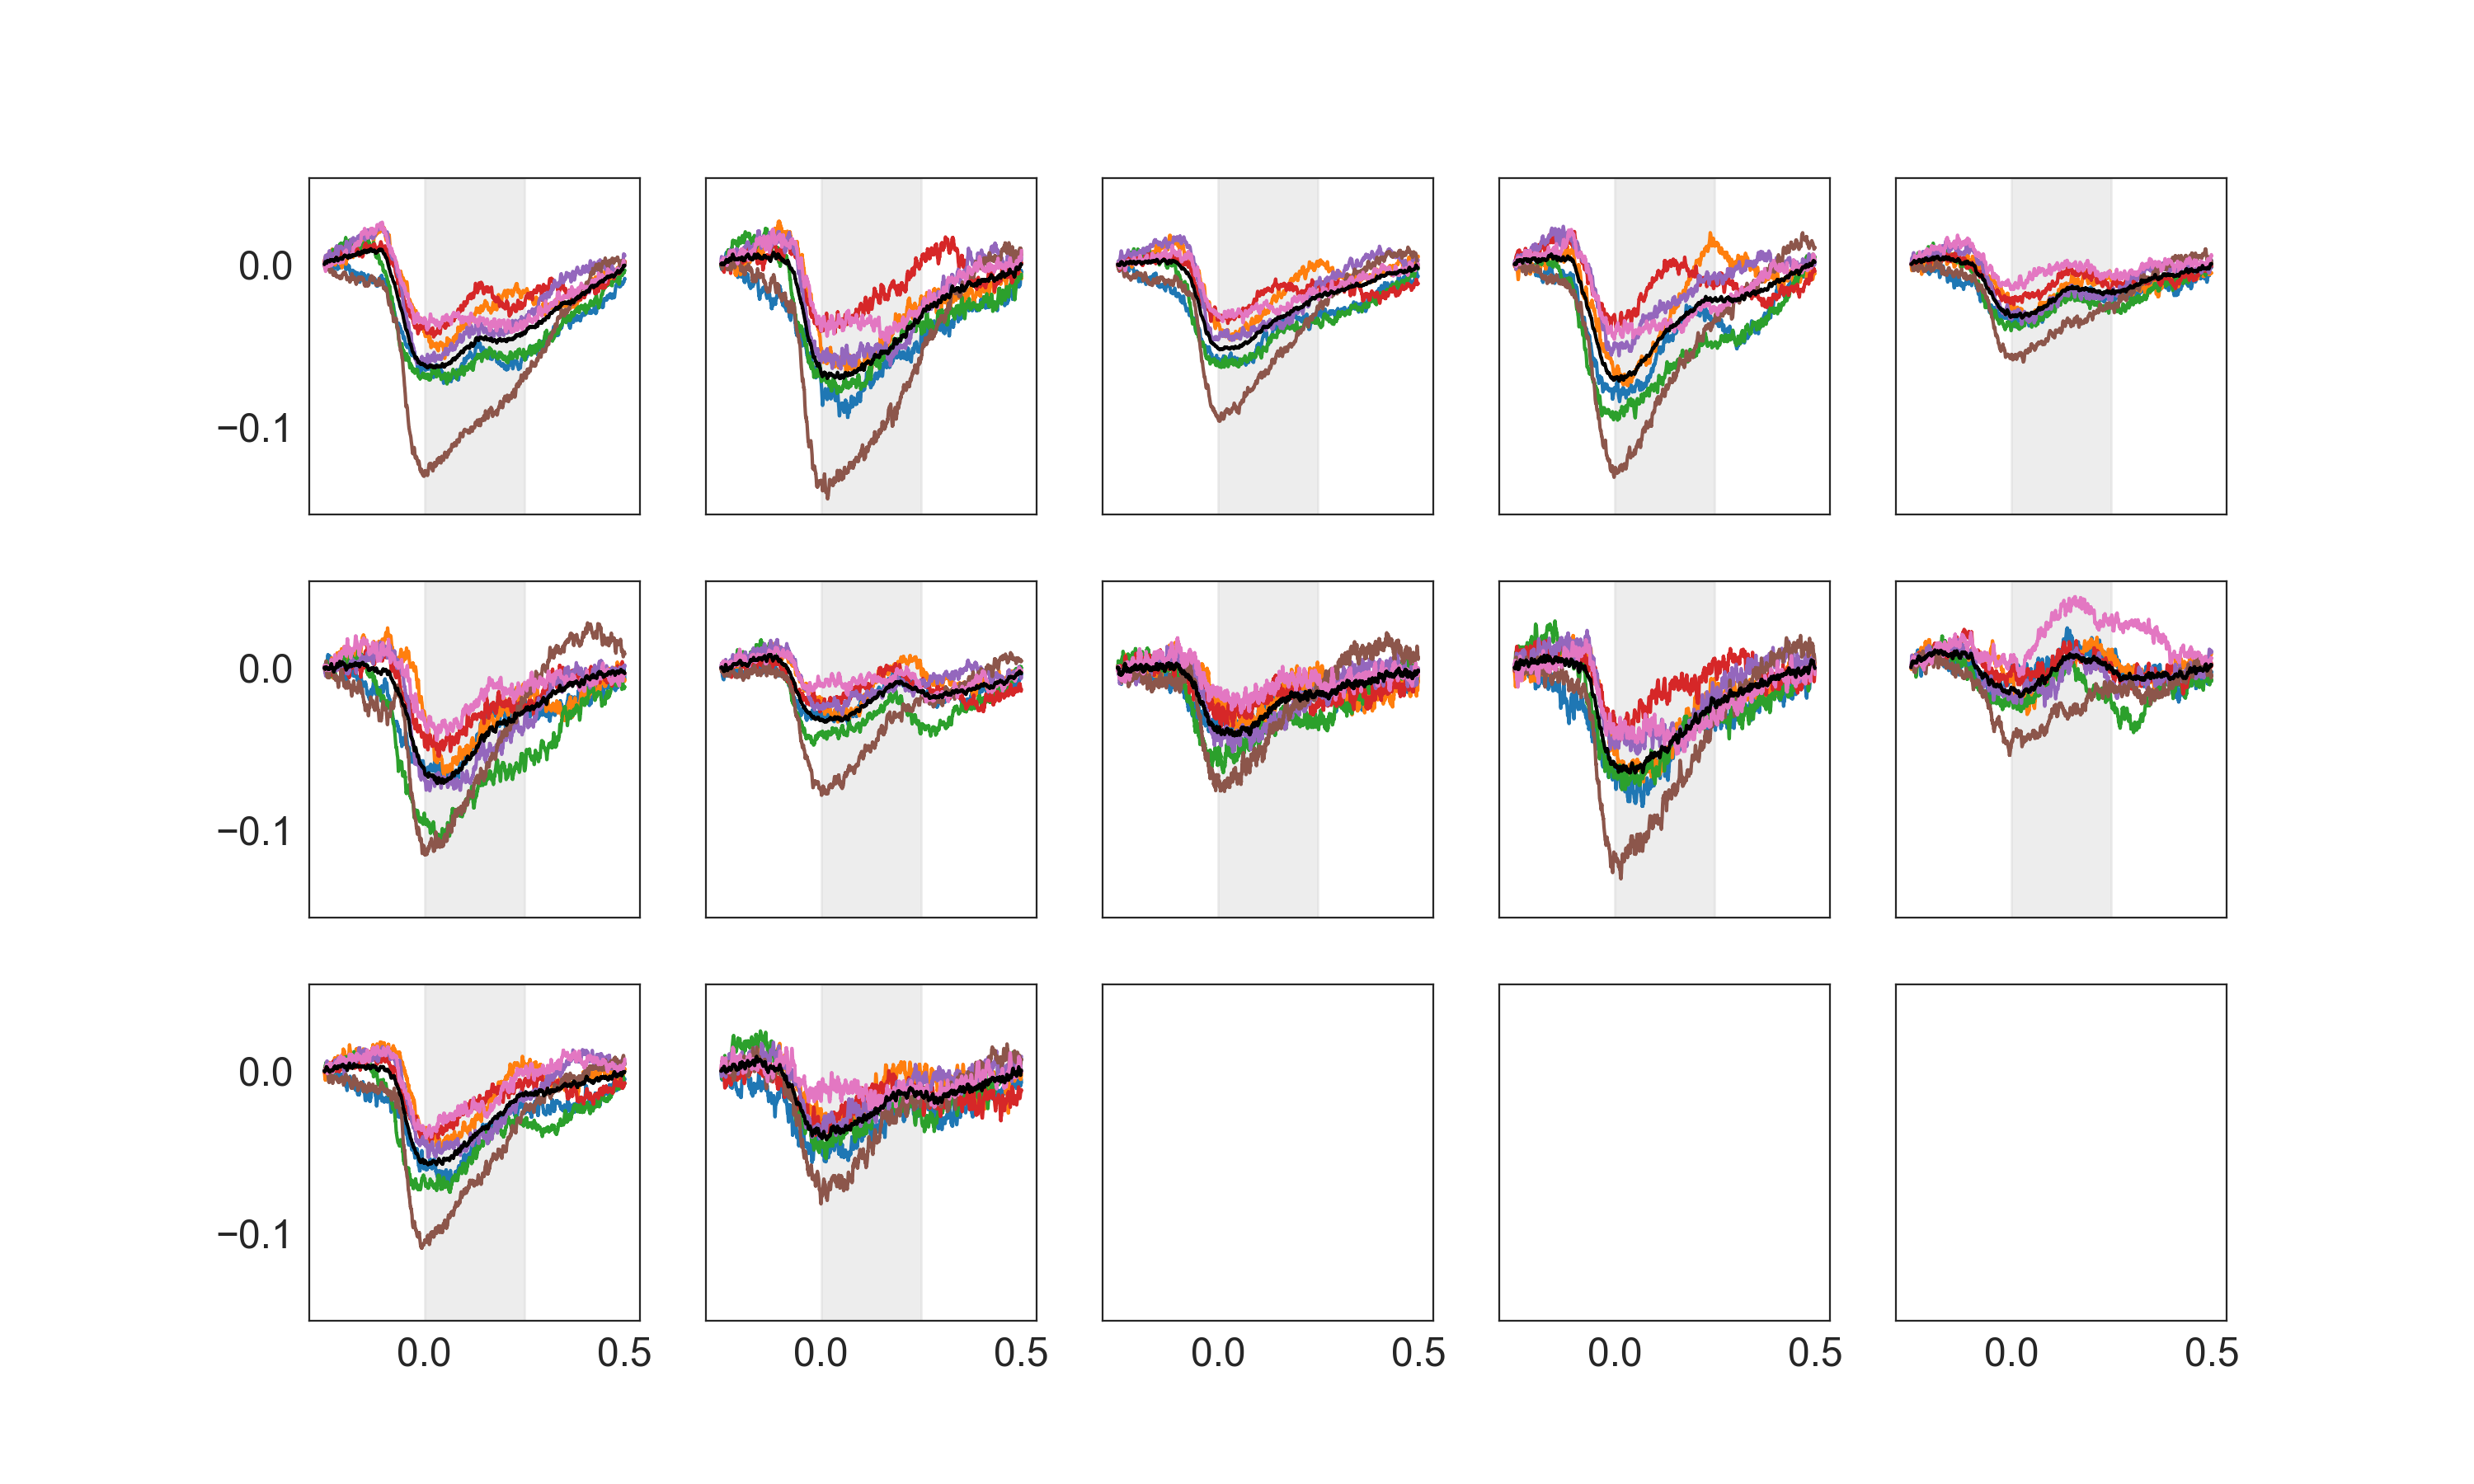

7


<IPython.core.display.Javascript object>


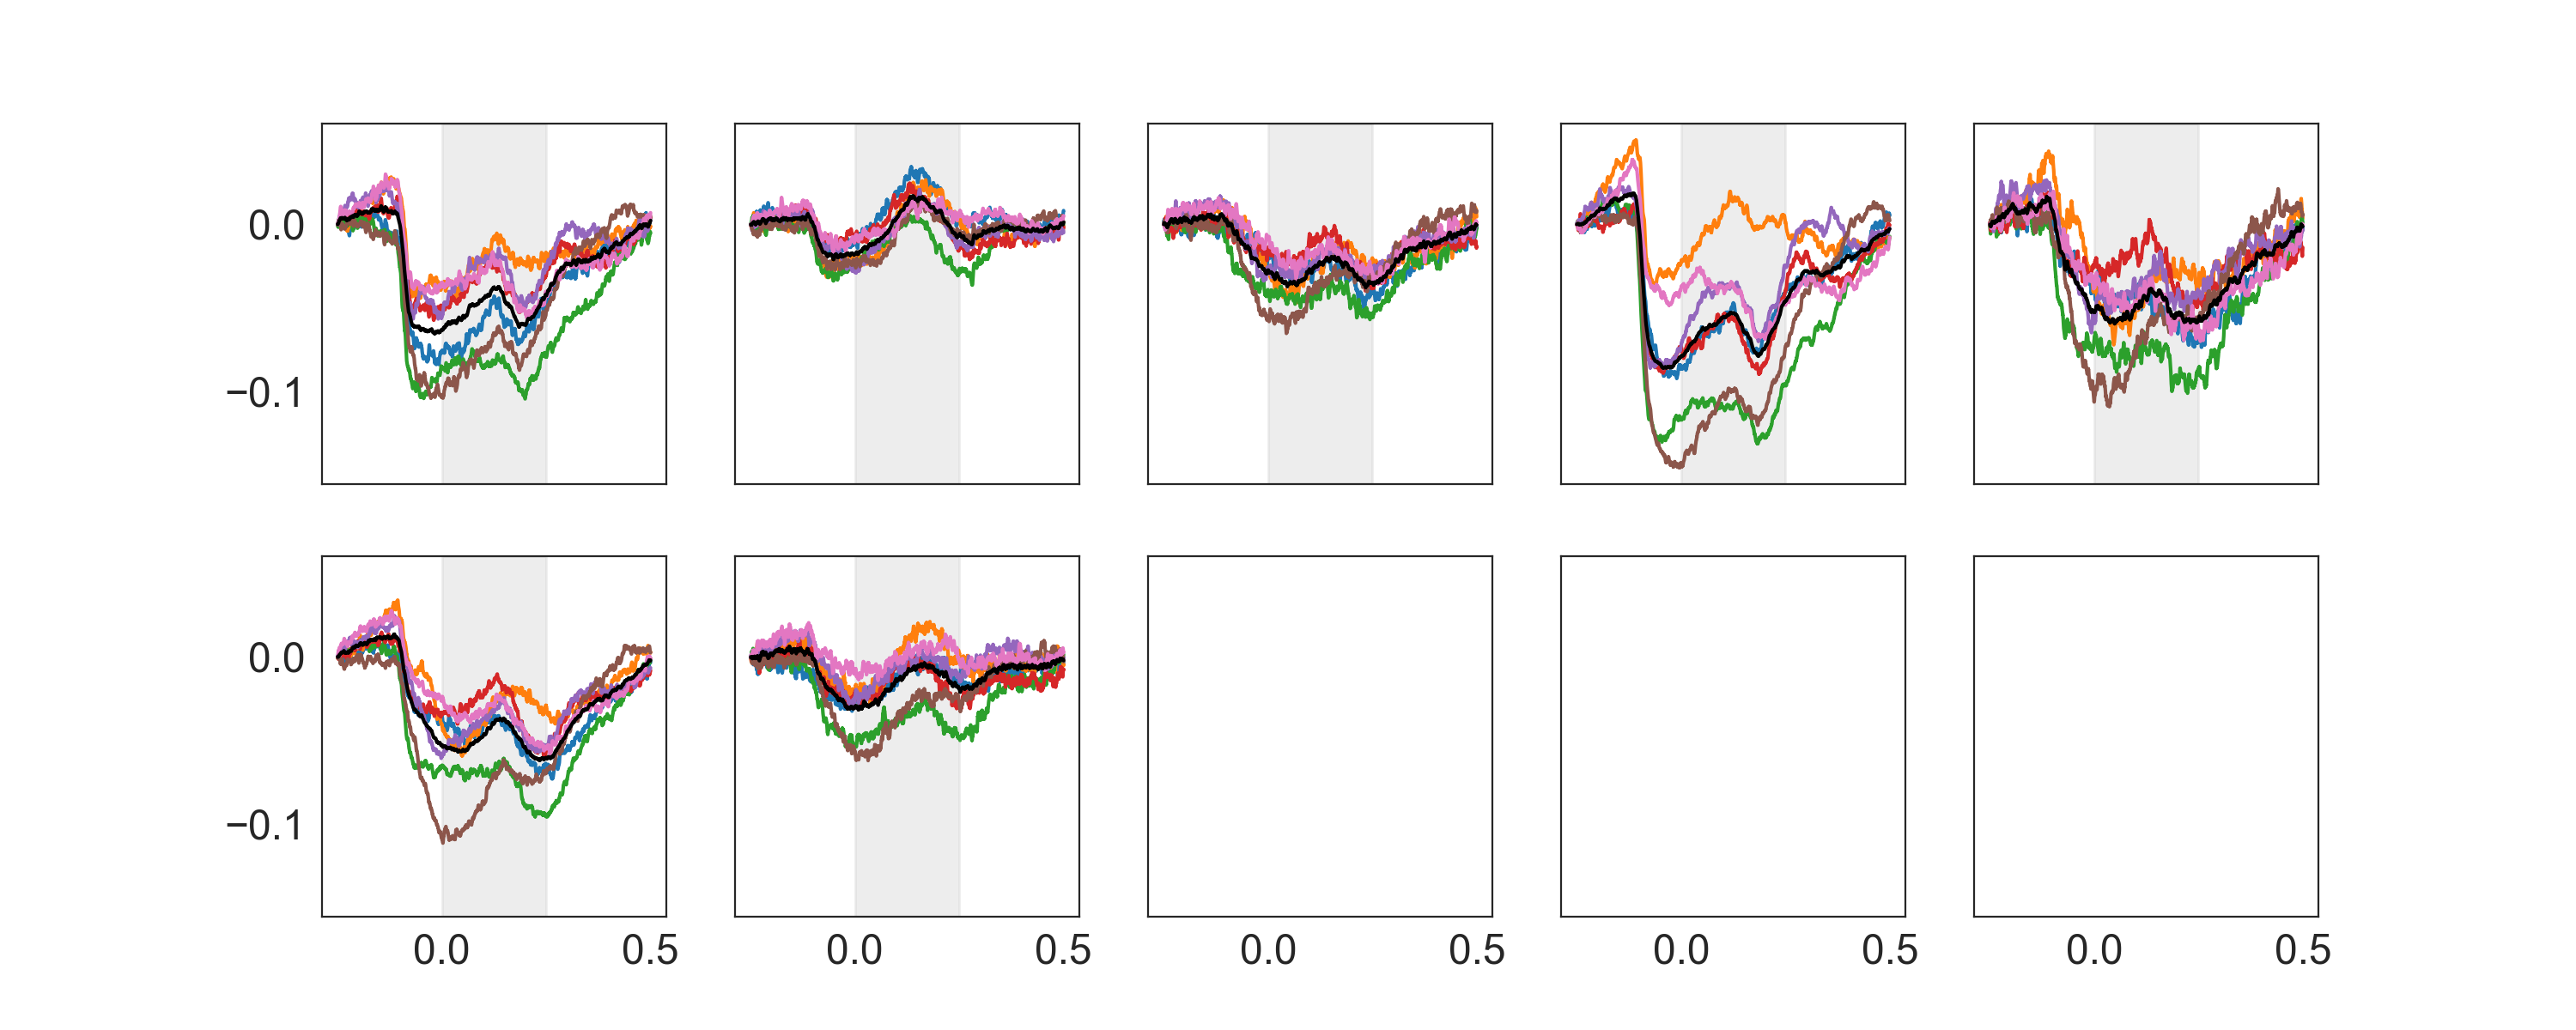

In [27]:
for i,dmd in enumerate([dmd1_data,dmd2_data]):
    dmd_rois = dmd['roi_ids']
    print(len(dmd_rois))
    n_col = 5
    n_row = len(dmd_rois)//n_col+1
    
    fig,axes=plt.subplots(n_row,n_col,sharex = True, sharey=True,figsize=(n_col*3,n_row*3))
    
    for ii,ax in enumerate(axes.flatten()):
        try:
            im_means = []
            for image in image_names:
                im_data = dmd['image_identity'][image]['mean'][ii]
                im_data = im_data - im_data[0]
                ax.plot(t[:-1],im_data)
                im_means.append(im_data)
            mean = np.mean(im_means,axis=0)
            ax.plot(t[:-1],mean,color='k')
            
            ax.axvspan(0.0,0.25,color='lightgray',alpha=0.4,zorder=0)
            fig.suptitle()
        except:
            pass

In [11]:
mds = [1, 2]

X = []
means = []
roi_metadata = []

expected_n_features = None
expected_n_images = None
expected_trace_length = None

sessions = [0,2,6,7,8,10,11,16,17,18]

for asset in np.array(assets)[sessions]:
    session_id = str(asset.session_id)
    subject_id = asset.subject_id
    metadata = asset.metadata

    datapath = (
        asset.derived_dir
        / "voltage"
        / "voltage_mean_dff_robust_f0_trial.npz"
    )

    print(f"Session: {session_id}")
    print(f"Loading: {datapath}")

    if not datapath.exists():
        print("  File not found; skipping session.\n")
        continue

    data = np.load(datapath, allow_pickle=True)["data"][0]

    for dmd_num in dmds:
        dmd_key = f"DMD{dmd_num}"

        if dmd_key not in data:
            print(f"  {dmd_key} not found; skipping.")
            continue

        dmd = data[dmd_key]
        dmd_rois = np.asarray(dmd["roi_ids"])

        # Sorting makes image concatenation deterministic within each session.
        image_names = sorted(dmd["image_identity"].keys(), key=str)

        depth = metadata.get(f"dmd{dmd_num}_depth", np.nan)

        print(
            f"  {dmd_key}: {len(dmd_rois)} ROIs, "
            f"depth = {depth} µm, "
            f"session type = {metadata.get('session_type', np.nan)}"
        )

        for roi_index, roi_id in enumerate(dmd_rois):
            try:
                image_responses = []

                for image_name in image_names:
                    mean_array = np.asarray(
                        dmd["image_identity"][image_name]["mean"]
                    )

                    im_data = np.asarray(
                        mean_array[roi_index],
                        dtype=float,
                    ).squeeze()

                    if im_data.ndim != 1:
                        raise ValueError(
                            f"Expected 1D mean trace, got {im_data.shape}"
                        )

                    # Retains your current baseline convention.
                    im_data = im_data - im_data[0]
                    image_responses.append(im_data)

                # Check that image traces have equal duration.
                image_lengths = [len(x) for x in image_responses]

                if len(set(image_lengths)) != 1:
                    raise ValueError(
                        f"Unequal image trace lengths: {image_lengths}"
                    )

                concatenated_response = np.concatenate(image_responses)
                mean_response = np.mean(
                    np.stack(image_responses, axis=0),
                    axis=0,
                )

                # PCA requires the same number of features for every ROI.
                if expected_n_features is None:
                    expected_n_features = len(concatenated_response)
                    expected_n_images = len(image_names)
                    expected_trace_length = image_lengths[0]

                if len(concatenated_response) != expected_n_features:
                    raise ValueError(
                        f"Feature length {len(concatenated_response)} "
                        f"does not match expected {expected_n_features}"
                    )

                roi_id_string = (
                    roi_id.decode()
                    if isinstance(roi_id, bytes)
                    else str(roi_id)
                )

                roi_uid = f"{session_id}__{dmd_key}__{roi_id_string}"

                X.append(concatenated_response)
                means.append(mean_response)

                roi_metadata.append(
                    {
                        # Unique observation identifiers
                        "roi_uid": roi_uid,
                        "roi_id": roi_id_string,
                        "roi_index": roi_index,
                        "dmd": dmd_key,
                        "dmd_num": dmd_num,

                        # Session identifiers
                        "session_id": session_id,
                        "subject_id": subject_id,
                        "session_number": metadata.get(
                            "session_#", np.nan
                        ),
                        "session_date": metadata.get(
                            "session_date", pd.NaT
                        ),

                        # Experimental factors
                        "depth_um": depth,
                        "session_type": metadata.get(
                            "session_type", np.nan
                        ),
                        "stimulus": metadata.get(
                            "stimulus", np.nan
                        ),
                        "paradigm": metadata.get(
                            "paradigm", np.nan
                        ),
                        "indicator1": metadata.get(
                            "indicator1", np.nan
                        ),
                        "quality": metadata.get(
                            "quality", np.nan
                        ),
                        "flags": metadata.get(
                            "flags", np.nan
                        ),

                        # Useful response-structure information
                        "n_images": len(image_names),
                        "trace_length": image_lengths[0],
                        "image_names": tuple(map(str, image_names)),
                        "source_path": str(datapath),
                    }
                )

            except Exception as exc:
                print(
                    f"    Could not extract ROI {roi_id!r} "
                    f"from {dmd_key}: {exc}"
                )

    print()

Session: 826031_2026-01-30_15-04-02
Loading: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\analysis\derived\voltage\voltage_mean_dff_robust_f0_trial.npz
  DMD1: 12 ROIs, depth = 25 µm, session type = familiar
  DMD2: 13 ROIs, depth = 250 µm, session type = familiar

Session: 826031_2026-02-02_10-23-53
Loading: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-02_10-23-53\analysis\derived\voltage\voltage_mean_dff_robust_f0_trial.npz
  DMD1: 15 ROIs, depth = 25 µm, session type = familiar
  DMD2: 11 ROIs, depth = 250 µm, session type = familiar

Session: 826031_2026-02-06_10-21-20
Loading: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-06_10-21-20\analysis\derived\voltage\voltage_mean_dff_robust_f0_trial.npz
  DMD1: 19 ROIs, depth = 25 µm, session type = familiar
  DMD2: 11 ROIs, depth = 250 µm, session type = familiar

Session: 826031_2026-02-10_10-48-51
Loading: \\al

## Compute PCA

In [12]:
X = np.asarray(X, dtype=float)
means = np.asarray(means, dtype=float)
roi_meta = pd.DataFrame(roi_metadata)

print("X shape:", X.shape)
print("Mean-response shape:", means.shape)
print("Metadata shape:", roi_meta.shape)

assert X.shape[0] == means.shape[0]
assert X.shape[0] == len(roi_meta)
assert roi_meta["roi_uid"].is_unique
assert np.isfinite(X).all()

display(roi_meta.head())

X shape: (253, 56105)
Mean-response shape: (253, 8015)
Metadata shape: (253, 20)


,roi_uid,roi_id,roi_index,dmd,dmd_num,session_id,subject_id,session_number,session_date,depth_um,session_type,stimulus,paradigm,indicator1,quality,flags,n_images,trace_length,image_names,source_path
0,826031_2026-01-30_15-04-02__DMD1__DMD1_roi0000,DMD1_roi0000,0,DMD1,1,826031_2026-01-30_15-04-02,826031,2,2026-01-30,25,familiar,images_A,change_detection_passive,ASAP7y,good,NaN,7,8015,"(stimuli\images_A\imk00459.tiff, stimuli\image...",\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
1,826031_2026-01-30_15-04-02__DMD1__DMD1_roi0001,DMD1_roi0001,1,DMD1,1,826031_2026-01-30_15-04-02,826031,2,2026-01-30,25,familiar,images_A,change_detection_passive,ASAP7y,good,NaN,7,8015,"(stimuli\images_A\imk00459.tiff, stimuli\image...",\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
2,826031_2026-01-30_15-04-02__DMD1__DMD1_roi0002,DMD1_roi0002,2,DMD1,1,826031_2026-01-30_15-04-02,826031,2,2026-01-30,25,familiar,images_A,change_detection_passive,ASAP7y,good,NaN,7,8015,"(stimuli\images_A\imk00459.tiff, stimuli\image...",\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
3,826031_2026-01-30_15-04-02__DMD1__DMD1_roi0003,DMD1_roi0003,3,DMD1,1,826031_2026-01-30_15-04-02,826031,2,2026-01-30,25,familiar,images_A,change_detection_passive,ASAP7y,good,NaN,7,8015,"(stimuli\images_A\imk00459.tiff, stimuli\image...",\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
4,826031_2026-01-30_15-04-02__DMD1__DMD1_roi0004,DMD1_roi0004,4,DMD1,1,826031_2026-01-30_15-04-02,826031,2,2026-01-30,25,familiar,images_A,change_detection_passive,ASAP7y,good,NaN,7,8015,"(stimuli\images_A\imk00459.tiff, stimuli\image...",\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler(with_mean=True, with_std=True)
Xz = scaler.fit_transform(X)

n_components = min(10, Xz.shape[0] - 1, Xz.shape[1])

pca = PCA(n_components=n_components)
Xpca = pca.fit_transform(Xz)

for pc_index in range(Xpca.shape[1]):
    roi_meta[f"PC{pc_index + 1}"] = Xpca[:, pc_index]

print(
    "Variance explained by PC1–PC5:",
    pca.explained_variance_ratio_[:5],
)

Variance explained by PC1–PC5: [0.38450763 0.08999487 0.07219651 0.05687645 0.04134485]


## Plot PCA

<IPython.core.display.Javascript object>


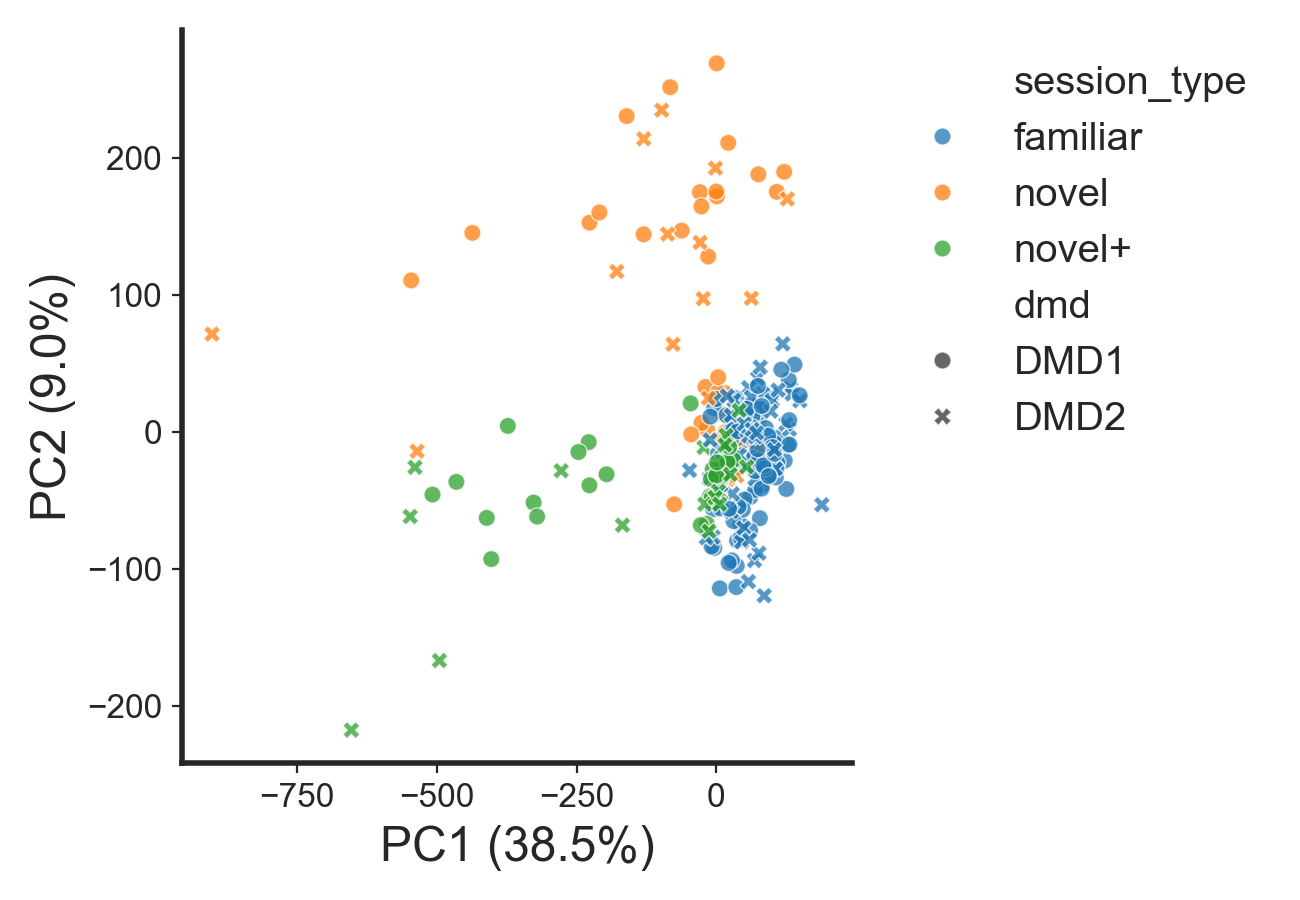

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

sns.scatterplot(
    data=roi_meta,
    x="PC1",
    y="PC2",
    hue="session_type",
    style="dmd",
    s=38,
    alpha=0.75,
    ax=ax,
)

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]:.1%})"
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]:.1%})"
)

ax.legend(title=None, 
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

sns.despine()
fig.tight_layout()

<IPython.core.display.Javascript object>


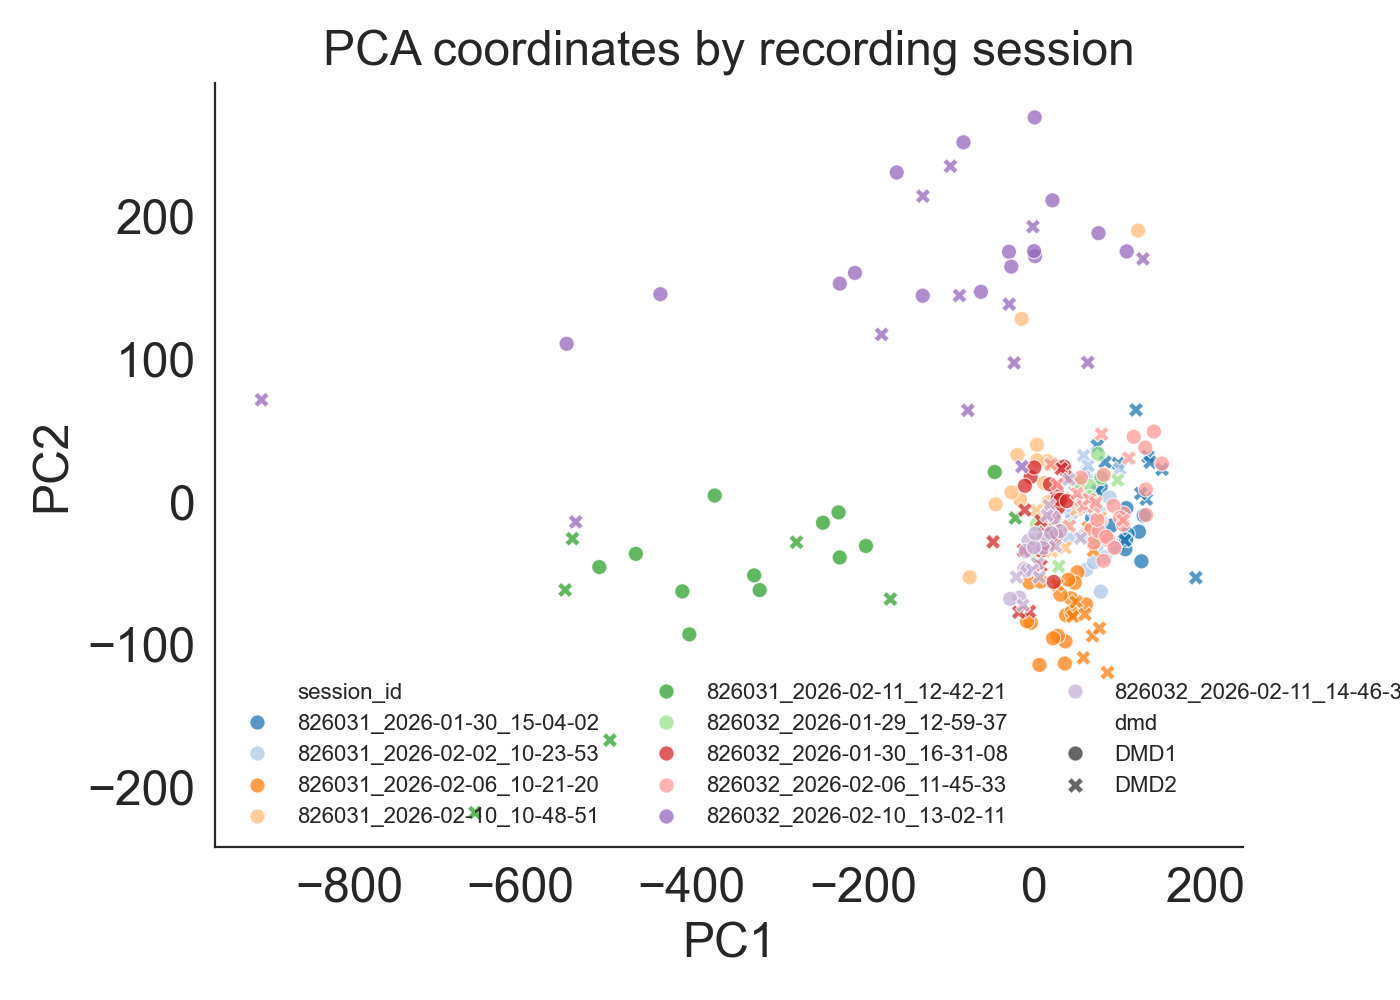

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(
    data=roi_meta,
    x="PC1",
    y="PC2",
    hue="session_id",
    style="dmd",
    palette='tab20',
    s=30,
    alpha=0.75,
    legend=True,
    ax=ax,
)
ax.set_title("PCA coordinates by recording session")
sns.despine()
ax.legend(ncols=3,fontsize=8,frameon=False)
fig.tight_layout()

<IPython.core.display.Javascript object>


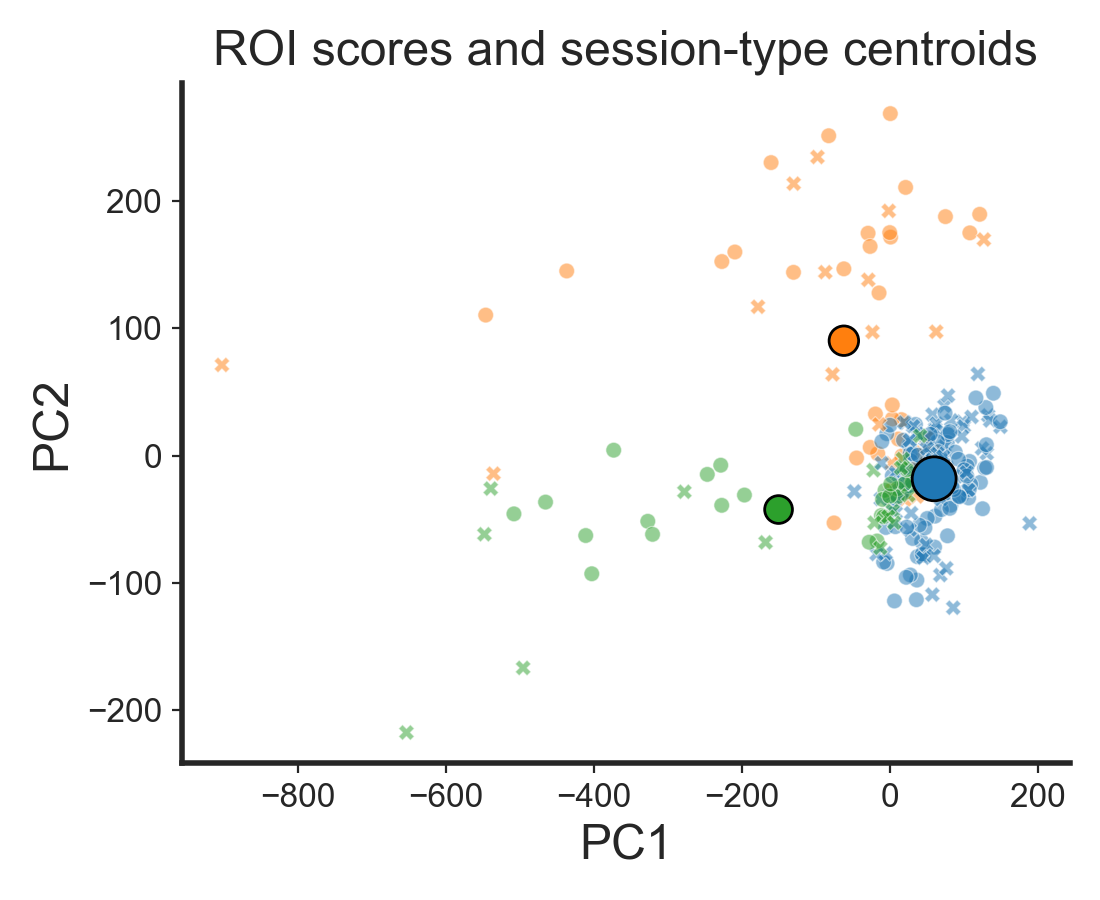

In [16]:
session_centroids = (
    roi_meta
    .groupby(
        ["session_type"],
        as_index=False,
    )
    .agg(
        PC1=("PC1", "mean"),
        PC2=("PC2", "mean"),
        n_rois=("roi_uid", "size"),
    )
)

fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

sns.scatterplot(
    data=roi_meta,
    x="PC1",
    y="PC2",
    hue="session_type",
    style="dmd",
    s=32,
    alpha=0.5,
    ax=ax,legend=False
)

sns.scatterplot(
    data=session_centroids,
    x="PC1",
    y="PC2",
    hue="session_type",
    size="n_rois",
    sizes=(100, 250),
    edgecolor="black",
    linewidth=1,
    ax=ax,legend=False
)
# ax.legend(frameon=False,fontsize=12)
ax.set_title("ROI scores and session-type centroids")
sns.despine()
fig.tight_layout()

In [17]:
pc_summary = (
    roi_meta
    .groupby(["session_type", "dmd"], dropna=False)
    .agg(
        n_rois=("roi_uid", "size"),
        n_sessions=("session_id", "nunique"),
        n_mice=("subject_id", "nunique"),
        mean_depth_um=("depth_um", "mean"),
        PC1_mean=("PC1", "mean"),
        PC1_sd=("PC1", "std"),
        PC2_mean=("PC2", "mean"),
        PC2_sd=("PC2", "std"),
    )
    .reset_index()
)

display(pc_summary)

,session_type,dmd,n_rois,n_sessions,n_mice,mean_depth_um,PC1_mean,PC1_sd,PC2_mean,PC2_sd
0,familiar,DMD1,89,6,2,25.0,61.859023,39.031907,-24.056719,35.650328
1,familiar,DMD2,70,6,2,250.0,57.547505,41.970005,-11.014530,38.468817
2,novel,DMD1,29,2,2,25.0,-59.439909,143.726392,112.291070,91.888773
3,novel,DMD2,23,2,2,250.0,-65.244667,225.103808,62.620424,86.001683
4,novel+,DMD1,25,2,2,25.0,-149.415847,182.987879,-35.183894,24.850322
5,novel+,DMD2,17,2,2,250.0,-151.411619,248.017974,-53.238139,58.297700


In [18]:
from scipy.stats import spearmanr


valid = roi_meta[["depth_um", "PC1", "PC2"]].dropna()

for pc_name in ["PC1", "PC2"]:
    rho, p = spearmanr(valid["depth_um"], valid[pc_name])
    print(f"{pc_name}: ROI-level rho={rho:.3f}, p={p:.3g}")

PC1: ROI-level rho=0.023, p=0.719
PC2: ROI-level rho=0.078, p=0.219


In [19]:
import statsmodels.formula.api as smf


model_df = roi_meta[
    [
        "PC1",
        "depth_um",
        "session_type",
        "session_id",
        "subject_id",
    ]
].dropna().copy()

model_df["session_type"] = model_df["session_type"].astype("category")

model = smf.mixedlm(
    "PC1 ~ depth_um + C(session_type)",
    data=model_df,
    groups=model_df["session_id"],
)

result = model.fit()
print(result.summary())

                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       PC1       
No. Observations:       253           Method:                   REML      
No. Groups:             10            Scale:                    8612.1827 
Min. group size:        17            Log-Likelihood:           -1507.2832
Max. group size:        33            Converged:                Yes       
Mean group size:        25.3                                              
--------------------------------------------------------------------------
                            Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
--------------------------------------------------------------------------
Intercept                    64.215   42.697  1.504 0.133  -19.470 147.901
C(session_type)[T.novel]   -113.821   84.349 -1.349 0.177 -279.143  51.501
C(session_type)[T.novel+]  -225.994   84.583 -2.672 0.008 -391.774 -60.214
depth_um                     -0.037    0.053

## Explained variance

In [20]:
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

<IPython.core.display.Javascript object>


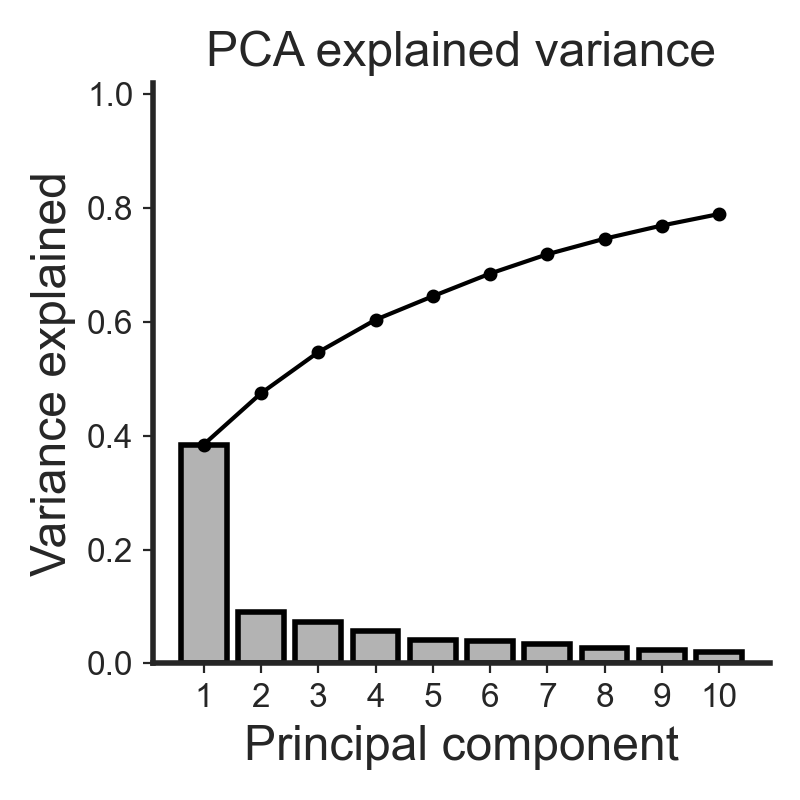

In [21]:
fig, ax = plt.subplots(figsize=(4, 4))
pcs = np.arange(1, len(explained_var) + 1)

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

ax.bar(pcs, explained_var, color='0.7', edgecolor='k',lw=2)
ax.plot(pcs, cumulative_var, 'o-', color='k', lw=1.5, ms=4)
ax.set_xlabel('Principal component')
ax.set_ylabel('Variance explained')
ax.set_xticks(pcs)
ax.set_ylim(0, 1.02)
ax.set_title('PCA explained variance')
sns.despine()

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()

filen = 'PCA_explained_variance'
# save_figure(fig,os.path.join(savepath,filen),formats=['.pdf','.png'],dpi=300)